In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
import jax
import jax.numpy as jnp
from flax import nnx
import jax.tree_util as jtu
import sys
sys.path.insert(0, '.')


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# H2分子几何构型
bond_length = 1.4  # 平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

print("="*60)
print("H2分子系统设置")
print("="*60)
print(f"键长: {bond_length} 埃")

# 创建分子对象
mol = gto.M(atom=geometry, basis='STO-3G')

# Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"\nHartree-Fock能量: {E_hf:.8f} Ha")

# FCI计算（参考值）
cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()

print(f"\nFCI能级（参考值）:")
print("-"*50)
for i, e in enumerate(E_fcis):
    exc_energy = (e - E_fcis[0]) * 27.2114
    if i == 0:
        print(f"  E{i} (基态)     = {e:.8f} Ha")
    else:
        print(f"  E{i} (第{i}激发态) = {e:.8f} Ha  激发能: {exc_energy:.4f} eV")

# 创建NetKet哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

H2分子系统设置
键长: 1.4 埃

Hartree-Fock能量: -0.94148065 Ha

FCI能级（参考值）:
--------------------------------------------------
  E0 (基态)     = -1.01546825 Ha
  E1 (第1激发态) = -0.87542794 Ha  激发能: 3.8107 eV
  E2 (第2激发态) = -0.42938376 Ha  激发能: 15.9482 eV
  E3 (第3激发态) = -0.26922131 Ha  激发能: 20.3064 eV


In [3]:
#==============================================================================
# 3. 神经网络模型（你的代码完全不变）
#==============================================================================
class SingleStateAnsatz(nnx.Module):
    def __init__(self, n_spin_orbitals: int, hidden_dim=16, *, rngs: nnx.Rngs):
        super().__init__()
        self.linear1 = nnx.Linear(n_spin_orbitals, hidden_dim, rngs=rngs, param_dtype=complex)
        self.linear2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs, param_dtype=complex)
        self.output = nnx.Linear(hidden_dim, 1, rngs=rngs, param_dtype=complex)

    def __call__(self, x):
        h = nnx.tanh(self.linear1(x))
        h = nnx.tanh(self.linear2(h))
        out = self.output(h)
        return jnp.squeeze(out)

class NESTotalAnsatz(nnx.Module):
    def __init__(self, n_spin_orbitals, n_states=2, hidden_dim=8, *, rngs: nnx.Rngs):
        super().__init__()
        self.n_states = n_states
        self.n_spin_orbitals = n_spin_orbitals
        self.single_ansatz_list = [
            SingleStateAnsatz(n_spin_orbitals, hidden_dim, rngs=nnx.Rngs(42+i))
            for i in range(n_states)
        ]

    def __call__(self, x_batch):
        K = self.n_states
        M = []
        for i in range(K):
            for j in range(K):
                val = self.single_ansatz_list[j](x_batch[i])
                M.append(val)
        M_mat = jnp.stack(M).reshape(K, K)
        psi_total = jnp.linalg.det(M_mat)
        return psi_total, M_mat



In [4]:
rngs = nnx.Rngs(42)
model = SingleStateAnsatz(4, 12,rngs=rngs)
model_state = nnx.state(model)


In [9]:
def forward(state,x):
  y, ffnn_state = nnx.call(state)(x)
  return y

In [11]:
n_orbitals = 2
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=n_orbitals,
    s=1/2,
    n_fermions_per_spin=(1, 1)
)

g = nk.graph.Graph(edges=[(0,1), (2,3)])
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=4, spin_symmetric=True, sweep_size=64
)
g = nk.graph.Graph(edges=[(0,1), (2,3)])
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=2, spin_symmetric=True, sweep_size=64
)
parameters1 = nnx.split(model)
sampler_state1 = sampler.init_state(forward, parameters1, seed=1)
sampler_state1 = sampler.reset(forward, parameters1, sampler_state1)
samples1, sampler_state1 = sampler.sample(
    forward, parameters1, state=sampler_state1, chain_length=100
)


In [ ]:
vstate = nk.vqs.MCState(sampler, model, n_samples=512)


In [23]:
print(vstate.parameters)

{'linear1': {'bias': Array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex128), 'kernel': Array([[-0.20509022-0.31775902j, -0.33366671-0.1592559j ,
         0.07511048-0.01285661j,  0.48032814+0.35539502j,
        -0.08448909-0.17092259j,  0.40490701-0.20833955j,
         0.43316182+0.47004878j, -0.52764356-0.34827962j,
         0.09345357+0.8292871j , -1.04444743-0.08975752j,
        -0.74199731+0.06109178j, -0.24439404-0.0333626j ],
       [ 0.32537153-0.42825702j,  0.32324629-0.06891861j,
        -0.30317425+0.2698035j ,  0.33701016-0.12756477j,
         0.55263029-0.22992893j,  0.18443318+0.51963488j,
        -0.10391099-0.04443816j,  0.50761603+0.4653993j ,
         0.2849317 +0.23498657j, -0.0620864 +0.02520219j,
         0.17602327+0.13025196j, -0.1517871 -0.36598473j],
       [-0.61123255+0.49653352j, -0.29719706+0.44543428j,
         0.0987181 +0.14588281j, -0.06180987+0.93594608j,
        -0.1267211 +0.185

In [25]:
E = vstate.expect(ha)
print(E)

-0.610+0.004j ± 0.012 [σ²=0.081, R̂=1.0001]


In [28]:
from tqdm import tqdm

energy_history = []
n_steps = 300
H=ha
# For every iteration (tqdm is just a progress bar)
for i in tqdm(range(n_steps)):
    # compute energy and gradient of the energy
    E, E_grad = vstate.expect_and_grad(H)
    # log the energy to a list
    energy_history.append(E.mean.real)
    # equivalent to vstate.parameters - 0.05*E_grad , but it performs this
    # function on every leaf of the dictionaries containing the set of parameters
    new_pars = jax.tree_util.tree_map(
        lambda x, y: x - 0.05 * y, vstate.parameters, E_grad
    )
    # actually update the parameters
    vstate.parameters = new_pars

100%|██████████| 300/300 [00:31<00:00,  9.62it/s]


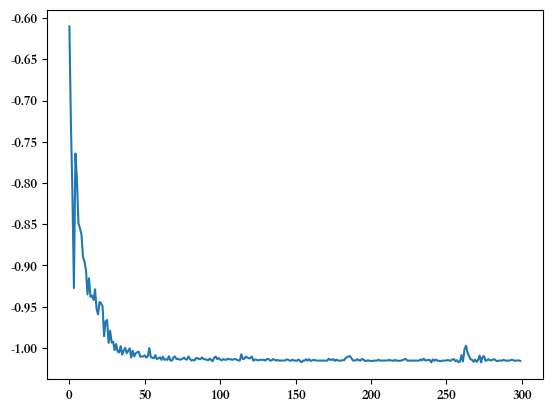

In [29]:
import matplotlib.pyplot as plt

plt.plot(energy_history)

In [42]:
data = vstate.sample(n_samples=1000)[0,:,:]

===== 4种组合出现频次 =====
(1, 0, 1, 0) : 459 次
(0, 1, 0, 1) : 41 次


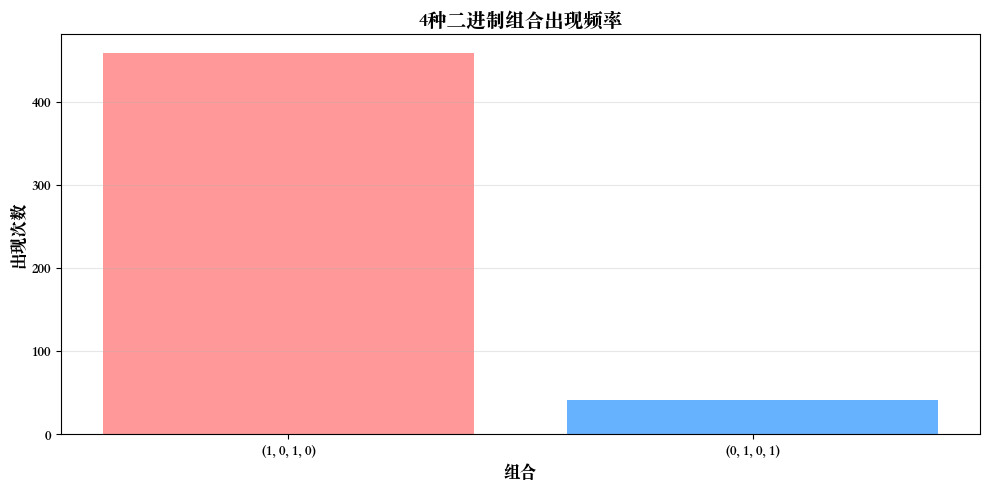

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ========== Mac 字体修复（必加） ==========
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Songti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号变方块
plt.rcParams['font.family'] = 'sans-serif'

# 你的数据（JAX数组）
#data = samples1[0, :, :]  # shape (100,4)

# ----------------------
# 关键修复：把 JAX 数组转成普通 numpy 数组
# ----------------------
data_np = np.asarray(data)  # 这一步解决报错！

# 把每一行转成元组
row_tuples = [tuple(row) for row in data_np]

# 统计组合频率
counter = Counter(row_tuples)

# 打印结果
print("===== 4种组合出现频次 =====")
for combo, count in counter.items():
    print(f"{combo} : {count} 次")

# ----------------------
# 画直方图
# ----------------------
combinations = [str(c) for c in counter.keys()]
frequencies = list(counter.values())

plt.figure(figsize=(10, 5))
plt.bar(combinations, frequencies, color=['#FF9999','#66B2FF','#99FF99','#FFCC99'])
plt.title('4种二进制组合出现频率', fontsize=14)
plt.xlabel('组合', fontsize=12)
plt.ylabel('出现次数', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
data_np

array([[[1, 0, 1, 0],
        [1, 0, 1, 0],
        [1, 0, 1, 0],
        ...,
        [1, 0, 1, 0],
        [1, 0, 1, 0],
        [1, 0, 1, 0]],

       [[1, 0, 1, 0],
        [1, 0, 1, 0],
        [1, 0, 1, 0],
        ...,
        [1, 0, 1, 0],
        [1, 0, 1, 0],
        [1, 0, 1, 0]]], dtype=int8)